# Train a Deep Learning Model on CIFAR-10


#### 3008ICT Deep Learning
#### Yusuf Abushaaban (S5301010)

In [ ]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from IPython.display import display


def seed_everything(seed=0):
    # All relevant random seeds for reproducibility.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda"), "cuda"
    return torch.device("cpu"), "cpu"


seed = 0
seed_everything(seed)

# Make CUDA runs deterministic when possible.
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device, backend = get_device()
print("backend:", backend, "| device:", device, "| torch:", torch.__version__)

backend: cuda | device: cuda | torch: 2.11.0+cu128


## Cell 2

In [ ]:
# Global config
data_dir = "./data"
val_ratio = 0.10
num_workers = 0

train_batch_size = 128
eval_batch_size = 256

# Epoch budgets for each experiment section.
softmax_epochs = 15
depth_epochs = 8
reg_epochs = 8
lr_epochs = 6
batch_epochs = 3

optimizer_name = "sgd"
print("Using fixed short epoch budgets on all backends.")

# CIFAR-10 normalization stats.
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

# Augmented transform for CNN training.
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# Transform for validation/test and softmax baseline.
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])


class TransformSubset(Dataset):
    # Dataset wrapper that applies a transform on selected indices.
    def __init__(self, base_dataset, indices, transform):
        self.base_dataset = base_dataset
        self.indices = np.asarray(indices, dtype=np.int64)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.base_dataset[int(self.indices[idx])]
        if self.transform is not None:
            x = self.transform(x)
        return x, y


def stratified_indices(targets, val_ratio=0.1, seed=0):
    # Build class-balanced train/validation splits.
    targets = np.asarray(targets)
    rng = np.random.default_rng(seed)

    train_indices = []
    val_indices = []

    for cls in np.unique(targets):
        cls_idx = np.where(targets == cls)[0]
        rng.shuffle(cls_idx)
        n_val = max(1, int(round(len(cls_idx) * val_ratio)))
        val_indices.extend(cls_idx[:n_val].tolist())
        train_indices.extend(cls_idx[n_val:].tolist())

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    return np.asarray(train_indices, dtype=np.int64), np.asarray(val_indices, dtype=np.int64)


# Load CIFAR-10 without transform; transforms are applied in TransformSubset.
base_train_raw = torchvision.datasets.CIFAR10(
    root=data_dir, train=True, download=True, transform=None
)
base_test_raw = torchvision.datasets.CIFAR10(
    root=data_dir, train=False, download=True, transform=None
)

train_indices, val_indices = stratified_indices(
    base_train_raw.targets, val_ratio=val_ratio, seed=seed
)

# Two training methods:
# ---Augmented (for CNN)
# ---Plain normalized (for softmax baseline)
train_set_aug = TransformSubset(base_train_raw, train_indices, train_transform)
train_set_plain = TransformSubset(base_train_raw, train_indices, eval_transform)

val_set = TransformSubset(base_train_raw, val_indices, eval_transform)
test_set = TransformSubset(base_test_raw, np.arange(len(base_test_raw)), eval_transform)

class_names = base_train_raw.classes


def build_loaders(train_batch_size=128, eval_batch_size=256, use_augmentation=True):
    # Pin memory for CUDA.
    pin = backend == "cuda"
    g = torch.Generator().manual_seed(seed)

    active_train_set = train_set_aug if use_augmentation else train_set_plain

    train_loader = DataLoader(
        active_train_set,
        batch_size=train_batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin,
        generator=g,
        drop_last=False,
    )
    val_loader = DataLoader(
        val_set,
        batch_size=eval_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )
    test_loader = DataLoader(
        test_set,
        batch_size=eval_batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )
    return train_loader, val_loader, test_loader


# Default loaders for CNN experiments (with augmentation)
train_loader, val_loader, test_loader = build_loaders(
    train_batch_size, eval_batch_size, use_augmentation=True
)

print(f"Train={len(train_indices)}, Val={len(val_indices)}, Test={len(test_set)}")

Using fixed short epoch budgets on all backends.


100%|██████████| 170M/170M [00:30<00:00, 5.68MB/s]


Train=45000, Val=5000, Test=10000


## Cell 3

In [ ]:
separator = "=" * 70


def print_run_header(model_name, input_size, output_size, epochs, lr, batch_size):
    # Consistent experiment header formatting.
    print(separator)
    print("CIFAR-10 NEURAL NETWORK TRAINING")
    print(separator)
    print(f"Model: {model_name}")
    print(f"Input size: {input_size}")
    print(f"Output size: {output_size}")
    print(f"Epochs: {epochs}")
    print(f"Learning rate: {lr}")
    print(f"Batch size: {batch_size}")
    print(f"Data directory: {data_dir}")
    print(f"Validation ratio: {val_ratio}")
    print(f"Random seed: {seed}")
    print(separator)


def print_dataset_report():
    # Print dataset shapes and class distribution in train & val splits
    targets = np.asarray(base_train_raw.targets)
    tr_counts = np.bincount(targets[train_indices], minlength=10)
    va_counts = np.bincount(targets[val_indices], minlength=10)

    x0, _ = train_set_plain[0]
    c, h, w = x0.shape

    print("Loading CIFAR-10 dataset...")
    print(f"Training data shape: ({len(base_train_raw)}, {c}, {h}, {w}), Labels shape: ({len(base_train_raw)},)")
    print(f"Test data shape: ({len(base_test_raw)}, {c}, {h}, {w}), Labels shape: ({len(base_test_raw)},)")
    print("Number of classes: 10")
    print()

    print(f"Creating validation split with {int(val_ratio * 100)}% of training data...")
    for cls, name in enumerate(class_names):
        total = int(tr_counts[cls] + va_counts[cls])
        print(
            f"Class {cls:>2} ({name:<10}): {total:4d} -> "
            f"Train: {int(tr_counts[cls]):4d}, Val: {int(va_counts[cls]):4d}"
        )

    print()
    print("Final splits:")
    print(f" Training set: {len(train_indices)} samples")
    print(f" Validation set: {len(val_indices)} samples")
    print(f" Test set: {len(test_set)} samples")
    print()

## Cell 4

In [ ]:
class SoftmaxRegression(nn.Module):
    # flatten image then classify.
    def __init__(self, num_classes=10):
        super().__init__()
        self.fc = nn.Linear(3 * 32 * 32, num_classes)

    def forward(self, x):
        return self.fc(x.flatten(1))


def split_units(total_units, n_stages=4):
    # splits units across stages as evenly
    base = total_units // n_stages
    rem = total_units % n_stages
    return [base + (1 if i < rem else 0) for i in range(n_stages)]


class ConvUnit(nn.Module):
    # Two-conv block with residual path and dropout
    def __init__(self, in_ch, out_ch, residual=False, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()
        self.use_residual = residual

        # Projection shortcut when channel dimensions do not match.
        if residual and in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.use_residual:
            out = out + self.shortcut(identity)

        out = self.relu(out)
        out = self.dropout(out)
        return out


class DepthCNN(nn.Module):
    # Depth CNN where conv_layers must be one of 2, 8, 16, 32.
    def __init__(self, conv_layers=8, num_classes=10, residual=False, dropout=0.0):
        super().__init__()
        if conv_layers not in (2, 8, 16, 32):
            raise ValueError("conv_layers must be one of: 2, 8, 16, 32")
        if conv_layers % 2 != 0:
            raise ValueError("conv_layers must be even")

        stage_channels = [32, 64, 128, 256]
        units_per_stage = split_units(conv_layers // 2, n_stages=len(stage_channels))

        layers = []
        in_ch = 3
        for stage_idx, (n_units, out_ch) in enumerate(zip(units_per_stage, stage_channels)):
            for _ in range(n_units):
                layers.append(ConvUnit(in_ch, out_ch, residual=residual, dropout=dropout))
                in_ch = out_ch
            # Downsample between stages when that stage has units.
            if n_units > 0 and stage_idx < len(stage_channels) - 1:
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

        self.features = nn.Sequential(*layers)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(in_ch, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def verify_model(model, name):
    # Check for output shape and parameter count.
    model = model.to(device)
    was_training = model.training
    model.eval()
    with torch.no_grad():
        x = torch.randn(4, 3, 32, 32, device=device)
        y = model(x)
    if was_training:
        model.train()
    assert y.shape == (4, 10), f"{name} wrong shape: {y.shape}"
    print(f"{name} verified | output={tuple(y.shape)} | params={sum(p.numel() for p in model.parameters()):,}")

## Cell 5

In [ ]:
def make_optimizer(model, lr, wd, optimizer_name="sgd"):
    # Force SGD to keep optimizer choice consistent across experiments.
    key = str(optimizer_name).strip().lower()
    if key != "sgd":
        raise ValueError(f"Unsupported optimizer_name: {optimizer_name}. This notebook is configured for SGD.")
    return torch.optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        nesterov=True,
        weight_decay=wd,
    )


def make_scheduler(optimizer, epochs, schedule="cosine"):
    # Optional learning-rate schedule.
    key = schedule.lower()
    if key == "none":
        return None
    if key == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    raise ValueError("schedule must be one of: none, cosine")


def run_epoch(model, loader, criterion, optimizer=None, max_grad_norm=None):
    # Train mode if optimizer is given, otherwise eval mode.
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    correct = 0
    total = 0
    start = time.perf_counter()

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        if train_mode:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train_mode):
            logits = model(x)
            loss = criterion(logits, y)

        if train_mode:
            loss.backward()
            if max_grad_norm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)

    elapsed = time.perf_counter() - start
    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)
    err = 1.0 - acc
    return avg_loss, acc, err, elapsed


def train_model_styled(
    model,
    model_label,
    train_loader,
    val_loader,
    test_loader,
    epochs=10,
    lr=0.001,
    wd=0.0005,
    optimizer_name="sgd",
    schedule="cosine",
    label_smoothing=0.0,
    max_grad_norm=1.0,
    eval_test_each_epoch=False,
    log_every=5,
):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = make_optimizer(model, lr=lr, wd=wd, optimizer_name=optimizer_name)
    scheduler = make_scheduler(optimizer, epochs=epochs, schedule=schedule)

    # Per-epoch history for plotting and analysis.
    hist = {
        "train_loss": [],
        "val_loss": [],
        "test_loss": [],
        "train_acc": [],
        "val_acc": [],
        "test_acc": [],
        "train_error": [],
        "val_error": [],
        "test_error": [],
        "train_time_sec": [],
        "epoch_time_sec": [],
        "lr": [],
    }

    best_val = float("-inf")
    best_epoch = None
    best_state = None

    print(f"Created {model_label}")
    print()
    print(f"Starting training for {epochs} epochs...")
    print(
        f"Optimizer: {optimizer_name} | Schedule: {schedule} | "
        f"Learning rate: {lr} | Weight decay: {wd} | Batch size: {train_loader.batch_size}"
    )

    for epoch in range(1, epochs + 1):
        epoch_start = time.perf_counter()

        tr_loss, tr_acc, tr_err, tr_sec = run_epoch(
            model, train_loader, criterion, optimizer=optimizer, max_grad_norm=max_grad_norm
        )
        va_loss, va_acc, va_err, _ = run_epoch(model, val_loader, criterion)

        # Test evaluation during training
        te_loss, te_acc, te_err = np.nan, np.nan, np.nan
        if eval_test_each_epoch:
            te_loss, te_acc, te_err, _ = run_epoch(model, test_loader, criterion)

        if scheduler is not None:
            scheduler.step()

        epoch_sec = time.perf_counter() - epoch_start
        cur_lr = optimizer.param_groups[0]["lr"]

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["test_loss"].append(te_loss)

        hist["train_acc"].append(tr_acc)
        hist["val_acc"].append(va_acc)
        hist["test_acc"].append(te_acc)

        hist["train_error"].append(tr_err)
        hist["val_error"].append(va_err)
        hist["test_error"].append(te_err)

        hist["train_time_sec"].append(tr_sec)
        hist["epoch_time_sec"].append(epoch_sec)
        hist["lr"].append(cur_lr)

        if epoch == 1 or epoch % log_every == 0 or epoch == epochs:
            msg = (
                f"Epoch {epoch:>2}/{epochs:<2} | "
                f"Train Loss: {tr_loss:.4f} | Val Loss: {va_loss:.4f} | "
                f"Train Acc: {tr_acc*100:6.2f}% | Val Acc: {va_acc*100:6.2f}% | "
                f"LR: {cur_lr:.2e} | Train Time: {tr_sec:5.2f}s"
            )
            if eval_test_each_epoch:
                msg += f" | Test Acc: {te_acc*100:6.2f}%"
            print(msg)

        # Keep the model state from the best validation epoch.
        if va_acc > best_val:
            best_val = va_acc
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            print("    *** New best validation accuracy! ***")

    if best_state is not None:
        model.load_state_dict(best_state)

    # Final test metrics are measured using the best-validation checkpoint.
    te_loss_best, te_acc_best, te_err_best, _ = run_epoch(model, test_loader, criterion)

    i = max(best_epoch - 1, 0)
    summary = {
        "Best Epoch": best_epoch,
        "Train Loss @ Best Val": hist["train_loss"][i],
        "Val Loss @ Best Val": hist["val_loss"][i],
        "Test Loss @ Best Val": te_loss_best,
        "Train Acc @ Best Val": hist["train_acc"][i],
        "Val Acc @ Best Val": hist["val_acc"][i],
        "Test Acc @ Best Val": te_acc_best,
        "Train Error @ Best Val": hist["train_error"][i],
        "Val Error @ Best Val": hist["val_error"][i],
        "Test Error @ Best Val": te_err_best,
        "Total Time (s)": float(np.sum(hist["epoch_time_sec"])),
        "Train Time (s)": float(np.sum(hist["train_time_sec"])),
    }

    print()
    print(separator)
    print(
        f"Best epoch: {summary['Best Epoch']} | "
        f"Best Val Acc: {summary['Val Acc @ Best Val']*100:.2f}% | "
        f"Test Acc @ Best Val: {summary['Test Acc @ Best Val']*100:.2f}%"
    )
    print(separator)
    print()

    return hist, summary


def summary_row(name, summary, extra=None):
    # Build one row for experiment result tables.
    row = {"Experiment": name}
    row.update(summary)
    if extra is not None:
        row.update(extra)
    return row

## Cell 6

CIFAR-10 NEURAL NETWORK TRAINING
Model: Linear (Softmax Regression)
Input size: 3072 (3x32x32)
Output size: 10
Epochs: 15
Learning rate: 0.005
Batch size: 128
Data directory: ./data
Validation ratio: 0.1
Random seed: 0
Loading CIFAR-10 dataset...
Training data shape: (50000, 3, 32, 32), Labels shape: (50000,)
Test data shape: (10000, 3, 32, 32), Labels shape: (10000,)
Number of classes: 10

Creating validation split with 10% of training data...
Class  0 (airplane  ): 5000 -> Train: 4500, Val:  500
Class  1 (automobile): 5000 -> Train: 4500, Val:  500
Class  2 (bird      ): 5000 -> Train: 4500, Val:  500
Class  3 (cat       ): 5000 -> Train: 4500, Val:  500
Class  4 (deer      ): 5000 -> Train: 4500, Val:  500
Class  5 (dog       ): 5000 -> Train: 4500, Val:  500
Class  6 (frog      ): 5000 -> Train: 4500, Val:  500
Class  7 (horse     ): 5000 -> Train: 4500, Val:  500
Class  8 (ship      ): 5000 -> Train: 4500, Val:  500
Class  9 (truck     ): 5000 -> Train: 4500, Val:  500

Final spli

,Experiment,Best Epoch,Train Loss @ Best Val,Val Loss @ Best Val,Test Loss @ Best Val,Train Acc @ Best Val,Val Acc @ Best Val,Test Acc @ Best Val,Train Error @ Best Val,Val Error @ Best Val,Test Error @ Best Val,Total Time (s),Train Time (s),Part,Train Seconds/Epoch
0,Softmax Regression,15,1.567937,1.754557,1.743575,0.472267,0.4038,0.4033,0.527733,0.5962,0.5967,186.216276,169.383119,1,11.292208


Train error @ best val epoch: 0.5277
Test error  @ best val epoch: 0.5967


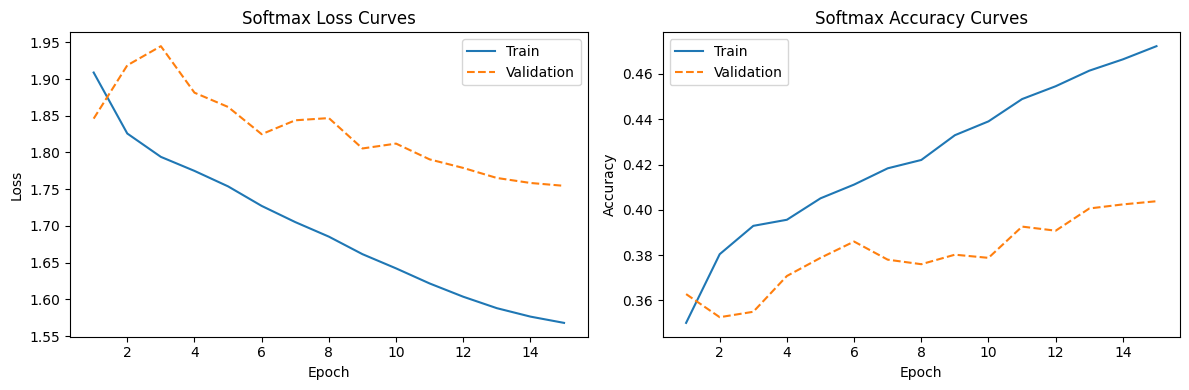

In [ ]:
# Train a Softmax model and print train/test error

print_run_header(
    model_name="Linear (Softmax Regression)",
    input_size="3072 (3x32x32)",
    output_size=10,
    epochs=softmax_epochs,
    lr=0.005,
    batch_size=train_batch_size,
)
print_dataset_report()

# Uses non-augmented training images.
soft_train_loader, soft_val_loader, soft_test_loader = build_loaders(
    train_batch_size, eval_batch_size, use_augmentation=False
)

soft_model = SoftmaxRegression()
verify_model(soft_model, "SoftmaxRegression")

hist_soft, sum_soft = train_model_styled(
    model=soft_model,
    model_label="Linear Classifier (Softmax Regression)",
    train_loader=soft_train_loader,
    val_loader=soft_val_loader,
    test_loader=soft_test_loader,
    epochs=softmax_epochs,
    lr=0.005,
    wd=0.0001,
    optimizer_name=optimizer_name,
    schedule="cosine",
    label_smoothing=0.0,
    max_grad_norm=None,
    eval_test_each_epoch=False,
    log_every=max(1, softmax_epochs // 5),
)

softmax_df = pd.DataFrame([summary_row("Softmax Regression", sum_soft, {"Part": "1"})])
softmax_df["Train Seconds/Epoch"] = softmax_df["Train Time (s)"] / softmax_epochs
display(softmax_df)

print(f"Train error @ best val epoch: {sum_soft['Train Error @ Best Val']:.4f}")
print(f"Test error  @ best val epoch: {sum_soft['Test Error @ Best Val']:.4f}")

# Plot softmax training curves.
ep = range(1, len(hist_soft["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(ep, hist_soft["train_loss"], label="Train")
ax[0].plot(ep, hist_soft["val_loss"], "--", label="Validation")
ax[0].set_title("Softmax Loss Curves")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend()

ax[1].plot(ep, hist_soft["train_acc"], label="Train")
ax[1].plot(ep, hist_soft["val_acc"], "--", label="Validation")
ax[1].set_title("Softmax Accuracy Curves")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Accuracy")
ax[1].legend()

plt.tight_layout()
plt.show()

## Cell 7

CIFAR-10 NEURAL NETWORK TRAINING
Model: CNN Depth 2
Input size: 3x32x32
Output size: 10
Epochs: 8
Learning rate: 0.003
Batch size: 128
Data directory: ./data
Validation ratio: 0.1
Random seed: 0
DepthCNN-2 verified | output=(4, 10) | params=21,226
Created CNN Depth 2

Starting training for 8 epochs...
Optimizer: sgd | Schedule: cosine | Learning rate: 0.003 | Weight decay: 0.0005 | Batch size: 128
Epoch  1/8  | Train Loss: 2.0654 | Val Loss: 1.9289 | Train Acc:  23.51% | Val Acc:  27.02% | LR: 2.89e-03 | Train Time: 21.71s
    *** New best validation accuracy! ***
Epoch  2/8  | Train Loss: 1.8669 | Val Loss: 1.8468 | Train Acc:  30.57% | Val Acc:  28.22% | LR: 2.56e-03 | Train Time: 21.06s
    *** New best validation accuracy! ***
    *** New best validation accuracy! ***
Epoch  4/8  | Train Loss: 1.7097 | Val Loss: 1.7329 | Train Acc:  36.36% | Val Acc:  34.02% | LR: 1.50e-03 | Train Time: 22.10s
    *** New best validation accuracy! ***
Epoch  6/8  | Train Loss: 1.6568 | Val Loss: 1.

,Depth,Train Loss @ Best Val,Val Loss @ Best Val,Train Acc @ Best Val,Val Acc @ Best Val,Test Acc @ Best Val,Train Seconds/Epoch,Generalization Gap
0,2,1.656808,1.684108,0.384289,0.3560,0.3719,21.312795,0.028289
1,8,1.067533,1.065166,0.618733,0.6160,0.6255,25.291214,0.002733
2,16,1.087731,1.077228,0.613378,0.6130,0.6173,30.590650,0.000378
3,32,1.780071,1.758653,0.307956,0.3094,0.3167,46.912517,-0.001444


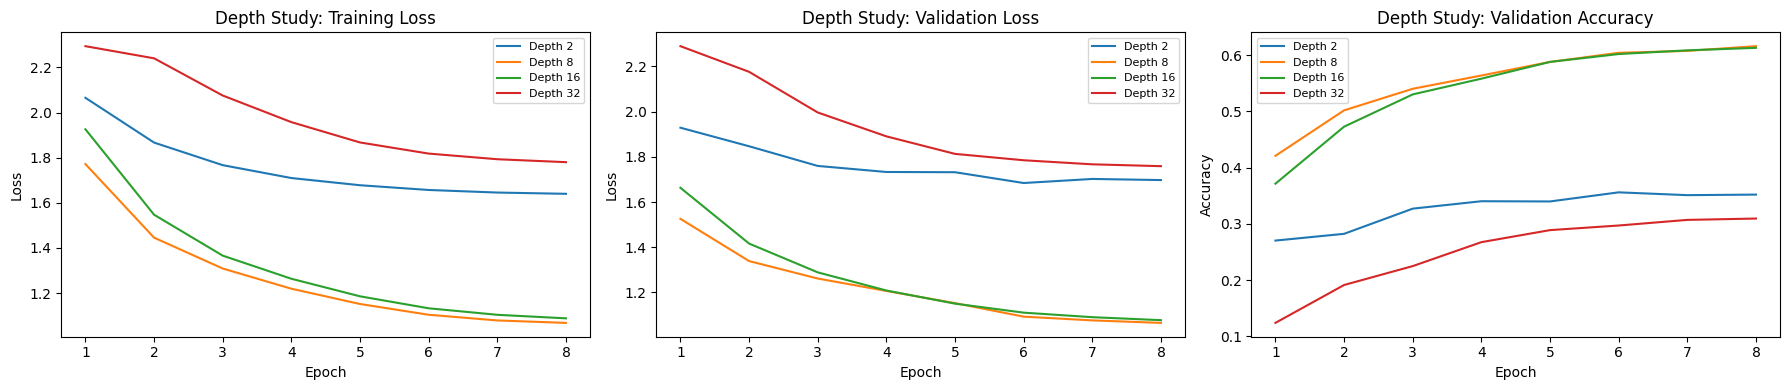

Depth analysis summary
Best depth by validation: 8 | Val Acc: 0.616 | Test Acc: 0.6255
Does increasing the network depth improve performance?
Not consistently in this run (Depth 32 does not outperform Depth 2 on validation).
Do deeper networks become harder to train?
Yes by compute cost: deeper model takes longer per epoch.
Optimization also appears harder: deeper model reached lower training accuracy in the same epoch budget.


In [ ]:
# Depth study

depths = [2, 8, 16, 32]
depth_histories = {}
depth_rows = []

for depth in depths:
    print_run_header(
        model_name=f"CNN Depth {depth}",
        input_size="3x32x32",
        output_size=10,
        epochs=depth_epochs,
        lr=3e-3,
        batch_size=train_batch_size,
    )

    # Models for 2(a) no residual, no dropout
    model = DepthCNN(conv_layers=depth, residual=False, dropout=0.0)
    verify_model(model, f"DepthCNN-{depth}")

    hist, summary = train_model_styled(
        model=model,
        model_label=f"CNN Depth {depth}",
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        epochs=depth_epochs,
        lr=0.003,
        wd=0.0005,
        optimizer_name=optimizer_name,
        schedule="cosine",
        label_smoothing=0.0,
        max_grad_norm=1.0,
        eval_test_each_epoch=False,
        log_every=max(1, depth_epochs // 4),
    )

    name = f"Depth {depth}"
    depth_histories[name] = hist
    depth_rows.append(
        summary_row(
            name,
            summary,
            {
                "Part": "2a",
                "Depth": depth,
                "Residual": False,
                "Dropout": 0.0,
                "Weight Decay": 0.0005,
            },
        )
    )

depth_df = pd.DataFrame(depth_rows).sort_values("Depth").reset_index(drop=True)
depth_df["Train Seconds/Epoch"] = depth_df["Train Time (s)"] / depth_epochs
depth_df["Generalization Gap"] = depth_df["Train Acc @ Best Val"] - depth_df["Val Acc @ Best Val"]

compare_cols = [
    "Depth",
    "Train Loss @ Best Val",
    "Val Loss @ Best Val",
    "Train Acc @ Best Val",
    "Val Acc @ Best Val",
    "Test Acc @ Best Val",
    "Train Seconds/Epoch",
    "Generalization Gap",
]
display(depth_df[compare_cols])

# Plot depth comparison curves.
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
for name, h in depth_histories.items():
    ep = range(1, len(h["train_loss"]) + 1)
    ax[0].plot(ep, h["train_loss"], label=name)
    ax[1].plot(ep, h["val_loss"], label=name)
    ax[2].plot(ep, h["val_acc"], label=name)

ax[0].set_title("Depth Study: Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].legend(fontsize=8)

ax[1].set_title("Depth Study: Validation Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend(fontsize=8)

ax[2].set_title("Depth Study: Validation Accuracy")
ax[2].set_xlabel("Epoch")
ax[2].set_ylabel("Accuracy")
ax[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Basic interpretation prints.
row_d2 = depth_df[depth_df["Depth"] == 2].iloc[0]
row_d32 = depth_df[depth_df["Depth"] == 32].iloc[0]
best_row = depth_df.sort_values("Val Acc @ Best Val", ascending=False).iloc[0]

print("Depth analysis summary")
print(
    "Best depth by validation:",
    int(best_row["Depth"]),
    "| Val Acc:",
    float(best_row["Val Acc @ Best Val"]),
    "| Test Acc:",
    float(best_row["Test Acc @ Best Val"]),
)

print("Does increasing the network depth improve performance?")
if row_d32["Val Acc @ Best Val"] > row_d2["Val Acc @ Best Val"]:
    print("Yes in this run (Depth 32 has higher validation accuracy than Depth 2).")
else:
    print("Not consistently in this run (Depth 32 does not outperform Depth 2 on validation).")

print("Do deeper networks become harder to train?")
harder_compute = row_d32["Train Seconds/Epoch"] > row_d2["Train Seconds/Epoch"]
harder_opt = row_d32["Train Acc @ Best Val"] < row_d2["Train Acc @ Best Val"]

if harder_compute:
    print("Yes by compute cost: deeper model takes longer per epoch.")
else:
    print("Not clearly by compute cost in this run.")

if harder_opt:
    print("Optimization also appears harder: deeper model reached lower training accuracy in the same epoch budget.")
else:
    print("Optimization difficulty is not obvious from training accuracy in this run.")


## Cell 8

Selected deep base depth from 2(a): 16
CIFAR-10 NEURAL NETWORK TRAINING
Model: Depth 16 | Deep Base (from 2a)
Input size: 3x32x32
Output size: 10
Epochs: 8
Learning rate: 0.003
Batch size: 128
Data directory: ./data
Validation ratio: 0.1
Random seed: 0
Deep Base (from 2a) verified | output=(4, 10) | params=2,810,218
Created Deep Base (from 2a)

Starting training for 8 epochs...
Optimizer: sgd | Schedule: cosine | Learning rate: 0.003 | Weight decay: 0.0005 | Batch size: 128
Epoch  1/8  | Train Loss: 1.9356 | Val Loss: 1.6858 | Train Acc:  27.50% | Val Acc:  36.44% | LR: 2.89e-03 | Train Time: 31.01s
    *** New best validation accuracy! ***
Epoch  2/8  | Train Loss: 1.6061 | Val Loss: 1.5122 | Train Acc:  40.03% | Val Acc:  44.22% | LR: 2.56e-03 | Train Time: 30.66s
    *** New best validation accuracy! ***
    *** New best validation accuracy! ***
Epoch  4/8  | Train Loss: 1.3087 | Val Loss: 1.2607 | Train Acc:  52.54% | Val Acc:  53.98% | LR: 1.50e-03 | Train Time: 30.84s
    *** New

,Experiment,Residual,Dropout,Weight Decay,Train Acc @ Best Val,Val Acc @ Best Val,Test Acc @ Best Val,Generalization Gap,Train Seconds/Epoch
0,Residual + WeightDecay,True,0.0,0.0005,0.652578,0.6412,0.6575,0.011378,32.009964
1,Deep Base (from 2a),False,0.0,0.0005,0.595356,0.5892,0.5968,0.006156,30.937678
2,Dropout + WeightDecay,False,0.2,0.0005,0.329800,0.2804,0.2808,0.049400,31.019509
3,Residual + Dropout + WeightDecay,True,0.2,0.0005,0.335422,0.2406,0.2482,0.094822,32.710302


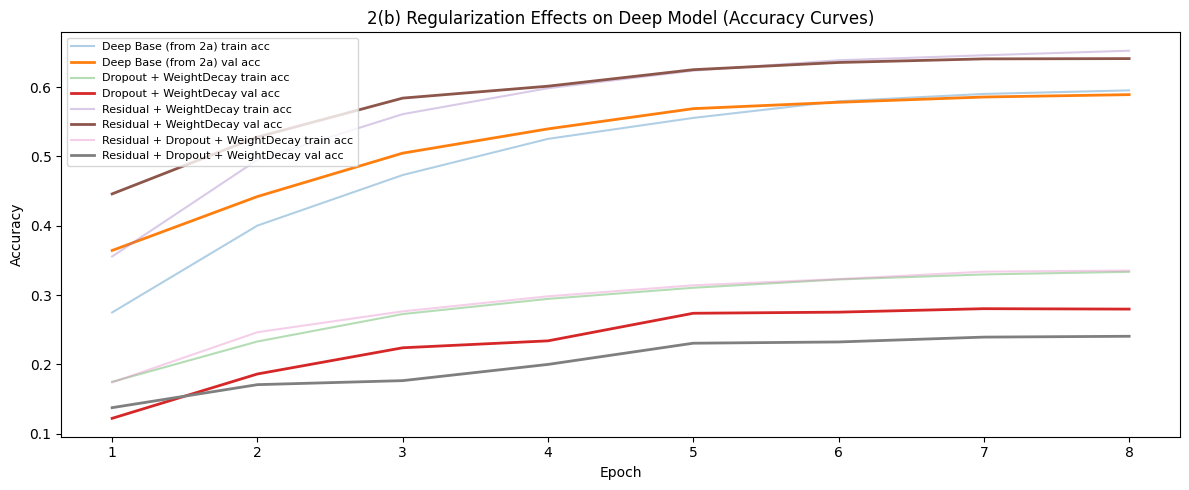

2(b) Trend analysis (accuracy only):
Best setup by validation accuracy: Residual + WeightDecay | residual=True | dropout=0.0 | wd=0.0005
Validation accuracy improved over the deep base model.
Generalization gap did not decrease clearly in this run.


In [8]:
# Improve a deep base model

# Select deeper baseline candidate using validation accuracy from 2(a).
deep_candidates = depth_df[depth_df["Depth"].isin([16, 32])].sort_values(
    "Val Acc @ Best Val", ascending=False
)
selected_deep_depth = int(deep_candidates.iloc[0]["Depth"])
print("Selected deep base depth from 2(a):", selected_deep_depth)

reg_configs = [
    {"name": "Deep Base (from 2a)", "residual": False, "dropout": 0.0, "wd": 0.0005},
    {"name": "Dropout + WeightDecay", "residual": False, "dropout": 0.2, "wd": 0.0005},
    {"name": "Residual + WeightDecay", "residual": True, "dropout": 0.0, "wd": 0.0005},
    {"name": "Residual + Dropout + WeightDecay", "residual": True, "dropout": 0.2, "wd": 0.0005},
]

reg_histories = {}
reg_rows = []

for cfg in reg_configs:
    print_run_header(
        model_name=f"Depth {selected_deep_depth} | {cfg['name']}",
        input_size="3x32x32",
        output_size=10,
        epochs=reg_epochs,
        lr=0.003,
        batch_size=train_batch_size,
    )

    model = DepthCNN(
        conv_layers=selected_deep_depth,
        residual=cfg["residual"],
        dropout=cfg["dropout"],
    )
    verify_model(model, cfg["name"])

    hist, summary = train_model_styled(
        model=model,
        model_label=cfg["name"],
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        epochs=reg_epochs,
        lr=0.003,
        wd=cfg["wd"],
        optimizer_name=optimizer_name,
        schedule="cosine",
        label_smoothing=0.0,
        max_grad_norm=1.0,
        eval_test_each_epoch=False,
        log_every=max(1, reg_epochs // 4),
    )

    reg_histories[cfg["name"]] = hist
    reg_rows.append(
        summary_row(
            cfg["name"],
            summary,
            {
                "Part": "2b",
                "Depth": selected_deep_depth,
                "Residual": cfg["residual"],
                "Dropout": cfg["dropout"],
                "Weight Decay": cfg["wd"],
            },
        )
    )

reg_df = pd.DataFrame(reg_rows).sort_values("Val Acc @ Best Val", ascending=False).reset_index(drop=True)
reg_df["Train Seconds/Epoch"] = reg_df["Train Time (s)"] / reg_epochs
reg_df["Generalization Gap"] = reg_df["Train Acc @ Best Val"] - reg_df["Val Acc @ Best Val"]

display(
    reg_df[
        [
            "Experiment",
            "Residual",
            "Dropout",
            "Weight Decay",
            "Train Acc @ Best Val",
            "Val Acc @ Best Val",
            "Test Acc @ Best Val",
            "Generalization Gap",
            "Train Seconds/Epoch",
        ]
    ]
)

# Overlay train and validation accuracy for each regularisation setup.
plt.figure(figsize=(12, 5))
for name, h in reg_histories.items():
    ep = range(1, len(h["train_acc"]) + 1)
    plt.plot(ep, h["train_acc"], alpha=0.35, label=f"{name} train acc")
    plt.plot(ep, h["val_acc"], linewidth=2, label=f"{name} val acc")

plt.title("2(b) Regularization Effects on Deep Model (Accuracy Curves)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

best_reg_name = str(reg_df.iloc[0]["Experiment"])
best_reg_cfg = next(cfg for cfg in reg_configs if cfg["name"] == best_reg_name)

base_row = reg_df[reg_df["Experiment"] == "Deep Base (from 2a)"].iloc[0]
best_row = reg_df.iloc[0]

print("2(b) Trend analysis (accuracy only):")
print(
    f"Best setup by validation accuracy: {best_reg_name} | "
    f"residual={best_reg_cfg['residual']} | "
    f"dropout={best_reg_cfg['dropout']} | "
    f"wd={best_reg_cfg['wd']:g}"
)

if best_row["Val Acc @ Best Val"] > base_row["Val Acc @ Best Val"]:
    print("Validation accuracy improved over the deep base model.")
else:
    print("No validation accuracy gain over the deep base model in this run.")

if best_row["Generalization Gap"] < base_row["Generalization Gap"]:
    print("Generalization gap decreased, indicating reduced overfitting.")
else:
    print("Generalization gap did not decrease clearly in this run.")



## Cell 9

Architecture used for LR analysis (selected from 2a/2b):
Depth=16, Residual=True, Dropout=0.0, WeightDecay=0.0005
CIFAR-10 NEURAL NETWORK TRAINING
Model: Depth 16 | Residual + WeightDecay | LR=1e-06
Input size: 3x32x32
Output size: 10
Epochs: 6
Learning rate: 1e-06
Batch size: 128
Data directory: ./data
Validation ratio: 0.1
Random seed: 0
Created LR=1e-06

Starting training for 6 epochs...
Optimizer: sgd | Schedule: none | Learning rate: 1e-06 | Weight decay: 0.0005 | Batch size: 128
Epoch  1/6  | Train Loss: 2.3187 | Val Loss: 2.3161 | Train Acc:  11.89% | Val Acc:  12.40% | LR: 1.00e-06 | Train Time: 32.39s
    *** New best validation accuracy! ***
Epoch  2/6  | Train Loss: 2.3188 | Val Loss: 2.3157 | Train Acc:  12.17% | Val Acc:  12.44% | LR: 1.00e-06 | Train Time: 32.01s
    *** New best validation accuracy! ***
    *** New best validation accuracy! ***
Epoch  4/6  | Train Loss: 2.3163 | Val Loss: 2.3139 | Train Acc:  12.44% | Val Acc:  12.76% | LR: 1.00e-06 | Train Time: 31.92s


,LR,Train Error @ Best Val,Val Error @ Best Val,Test Error @ Best Val,Val Acc @ Best Val,Test Acc @ Best Val,Train Seconds/Epoch,Epoch to 50% Val Acc
0,0.000001,0.876000,0.8710,0.8792,0.1290,0.1208,32.158318,NaN
1,0.000100,0.683822,0.6910,0.6703,0.3090,0.3297,31.739192,NaN
2,0.001000,0.467156,0.4622,0.4511,0.5378,0.5489,32.104483,5.0
3,0.010000,0.218644,0.2318,0.2320,0.7682,0.7680,32.073488,1.0
4,1.000000,0.598444,0.6274,0.6256,0.3726,0.3744,31.937941,NaN


Which learning rate achieves the highest test accuracy?
Best LR (by test): 0.01 | Test Acc: 0.768
Which learning rates lead to slow training time per epoch?


,LR,Train Seconds/Epoch,Train Time (s),Test Acc @ Best Val
0,0.000001,32.158318,192.949910,0.1208
2,0.001000,32.104483,192.626896,0.5489


Which learning rates converge slowly (epochs to 50% validation accuracy)?


,LR,Epoch to 50% Val Acc,Val Acc @ Best Val,Test Acc @ Best Val
0,0.000001,NaN,0.1290,0.1208
1,0.000100,NaN,0.3090,0.3297
4,1.000000,NaN,0.3726,0.3744
2,0.001000,5.0,0.5378,0.5489
3,0.010000,1.0,0.7682,0.7680


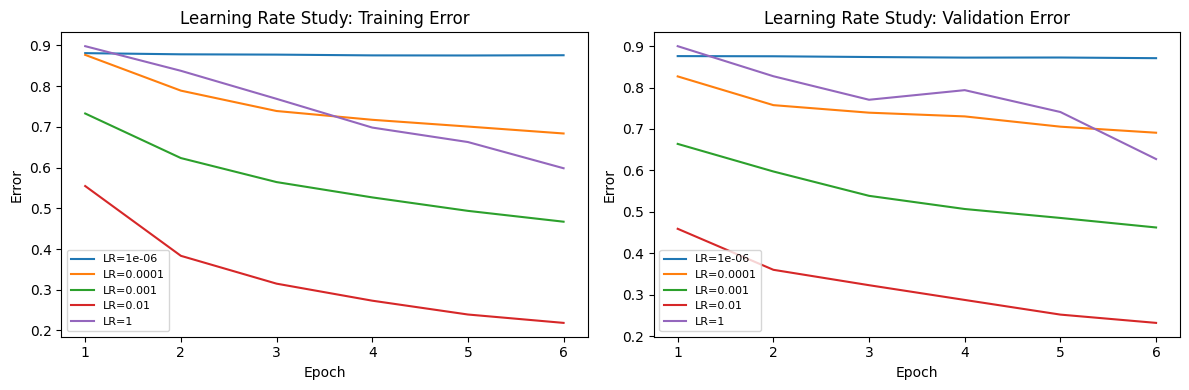

In [9]:
# Learning rate analysis

def epoch_to_reach_threshold(values, threshold):
    # Return first epoch index that reaches target threshold.
    for i, v in enumerate(values, start=1):
        if np.isfinite(v) and v >= threshold:
            return i
    return np.nan


lr_values = [0.000001, 0.0001, 0.001, 0.01, 1.0]
target_val_acc = 0.50

print("Architecture used for LR analysis (selected from 2a/2b):")
print(
    f"Depth={selected_deep_depth}, "
    f"Residual={best_reg_cfg['residual']}, "
    f"Dropout={best_reg_cfg['dropout']}, "
    f"WeightDecay={best_reg_cfg['wd']}"
)

lr_histories = {}
lr_rows = []

for lr in lr_values:
    print_run_header(
        model_name=f"Depth {selected_deep_depth} | {best_reg_name} | LR={lr}",
        input_size="3x32x32",
        output_size=10,
        epochs=lr_epochs,
        lr=lr,
        batch_size=train_batch_size,
    )

    model = DepthCNN(
        conv_layers=selected_deep_depth,
        residual=best_reg_cfg["residual"],
        dropout=best_reg_cfg["dropout"],
    )

    hist, summary = train_model_styled(
        model=model,
        model_label=f"LR={lr}",
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        epochs=lr_epochs,
        lr=lr,
        wd=best_reg_cfg["wd"],
        optimizer_name=optimizer_name,
        schedule="none",  # fixed LR to isolate LR effect
        label_smoothing=0.0,
        max_grad_norm=1.0,
        eval_test_each_epoch=False,
        log_every=max(1, lr_epochs // 3),
    )

    name = f"LR={lr:g}"
    lr_histories[name] = hist
    lr_rows.append(
        summary_row(
            name,
            summary,
            {
                "Part": "2c",
                "LR": lr,
                "Depth": selected_deep_depth,
                "Residual": best_reg_cfg["residual"],
                "Dropout": best_reg_cfg["dropout"],
                "Weight Decay": best_reg_cfg["wd"],
                f"Epoch to {int(target_val_acc*100)}% Val Acc": epoch_to_reach_threshold(
                    hist["val_acc"], target_val_acc
                ),
            },
        )
    )

lr_df = pd.DataFrame(lr_rows).sort_values("LR").reset_index(drop=True)
lr_df["Train Seconds/Epoch"] = lr_df["Train Time (s)"] / lr_epochs

display(
    lr_df[
        [
            "LR",
            "Train Error @ Best Val",
            "Val Error @ Best Val",
            "Test Error @ Best Val",
            "Val Acc @ Best Val",
            "Test Acc @ Best Val",
            "Train Seconds/Epoch",
            f"Epoch to {int(target_val_acc*100)}% Val Acc",
        ]
    ]
)

best_lr_test_row = lr_df.loc[lr_df["Test Acc @ Best Val"].idxmax()]
best_lr_val_row = lr_df.loc[lr_df["Val Acc @ Best Val"].idxmax()]
selected_lr = float(best_lr_val_row["LR"])

print("Which learning rate achieves the highest test accuracy?")
print(
    "Best LR (by test):",
    float(best_lr_test_row["LR"]),
    "| Test Acc:",
    float(best_lr_test_row["Test Acc @ Best Val"]),
)

# Compare speed implications of different learning rates.
slow_lr_time = lr_df.sort_values("Train Seconds/Epoch", ascending=False).head(2)
print("Which learning rates lead to slow training time per epoch?")
display(slow_lr_time[["LR", "Train Seconds/Epoch", "Train Time (s)", "Test Acc @ Best Val"]])

# Compare convergence speed to a target validation accuracy threshold.
slow_lr_convergence = lr_df.sort_values(
    by=f"Epoch to {int(target_val_acc*100)}% Val Acc",
    ascending=False,
    na_position="first",
)
print(f"Which learning rates converge slowly (epochs to {int(target_val_acc*100)}% validation accuracy)?")
display(
    slow_lr_convergence[
        ["LR", f"Epoch to {int(target_val_acc*100)}% Val Acc", "Val Acc @ Best Val", "Test Acc @ Best Val"]
    ]
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name, h in lr_histories.items():
    ep = range(1, len(h["train_error"]) + 1)
    ax[0].plot(ep, h["train_error"], label=name)
    ax[1].plot(ep, h["val_error"], label=name)

ax[0].set_title("Learning Rate Study: Training Error")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Error")
ax[0].legend(fontsize=8)

ax[1].set_title("Learning Rate Study: Validation Error")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Error")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Cell 10

Architecture/settings used (same as 2c):
Depth=16, Residual=True, Dropout=0.0, WeightDecay=0.0005, LR=0.01
CIFAR-10 NEURAL NETWORK TRAINING
Model: Depth 16 | Residual + WeightDecay | Batch=1
Input size: 3x32x32
Output size: 10
Epochs: 3
Learning rate: 0.01
Batch size: 1
Data directory: ./data
Validation ratio: 0.1
Random seed: 0
Created Batch Size=1

Starting training for 3 epochs...
Optimizer: sgd | Schedule: none | Learning rate: 0.01 | Weight decay: 0.0005 | Batch size: 1
Epoch  1/3  | Train Loss: 2.3242 | Val Loss: 2.3759 | Train Acc:  10.02% | Val Acc:  12.36% | LR: 1.00e-02 | Train Time: 493.33s
    *** New best validation accuracy! ***
Epoch  2/3  | Train Loss: 2.1392 | Val Loss: 2.2133 | Train Acc:  19.07% | Val Acc:  18.52% | LR: 1.00e-02 | Train Time: 487.50s
    *** New best validation accuracy! ***
Epoch  3/3  | Train Loss: 1.9662 | Val Loss: 2.4143 | Train Acc:  29.60% | Val Acc:  22.30% | LR: 1.00e-02 | Train Time: 488.26s
    *** New best validation accuracy! ***

Best e

,Batch Size,Train Error @ Best Val,Val Error @ Best Val,Test Error @ Best Val,Test Acc @ Best Val,Train Seconds/Epoch,Train Time (s)
0,1,0.704044,0.7770,0.7763,0.2237,489.697137,1469.091410
1,8,0.278644,0.2472,0.2411,0.7589,81.106249,243.318746
2,16,0.258000,0.2396,0.2248,0.7752,49.215211,147.645633
3,64,0.286067,0.2908,0.2878,0.7122,32.986751,98.960253
4,256,0.353244,0.3400,0.3442,0.6558,33.213441,99.640324


Which mini-batch size achieves the highest test accuracy?
Best batch size: 16 | Test Acc: 0.7752
Which mini-batch size is the slowest in training time?
Slowest batch size: 1 | Train Seconds/Epoch: 489.69713671166636


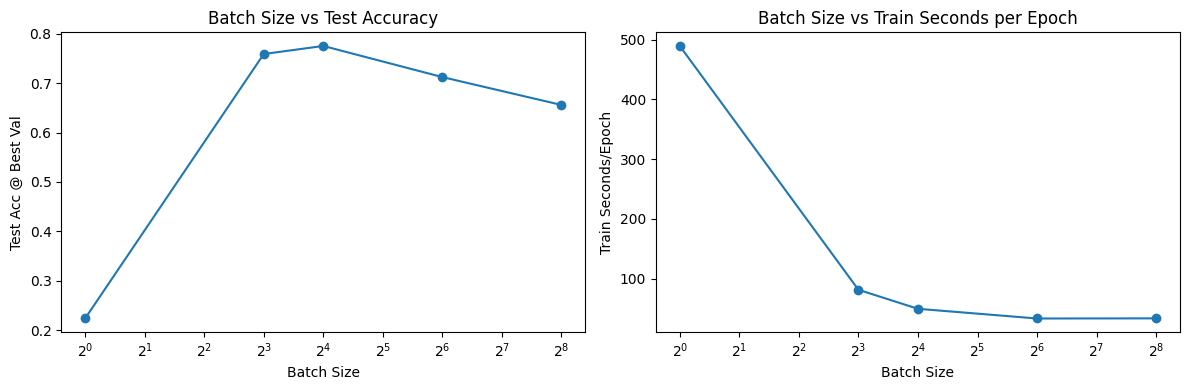

In [12]:
# Mini-batch size study

batch_sizes = [1, 8, 16, 64, 256]

print("Architecture/settings used (same as 2c):")
print(
    f"Depth={selected_deep_depth}, "
    f"Residual={best_reg_cfg['residual']}, "
    f"Dropout={best_reg_cfg['dropout']}, "
    f"WeightDecay={best_reg_cfg['wd']}, "
    f"LR={selected_lr}"
)

bs_histories = {}
bs_rows = []

for bs in batch_sizes:
    # Rebuild data loaders for each batch size.
    train_loader_bs, val_loader_bs, test_loader_bs = build_loaders(
        train_batch_size=bs,
        eval_batch_size=eval_batch_size,
        use_augmentation=True,
    )

    print_run_header(
        model_name=f"Depth {selected_deep_depth} | {best_reg_name} | Batch={bs}",
        input_size="3x32x32",
        output_size=10,
        epochs=batch_epochs,
        lr=selected_lr,
        batch_size=bs,
    )

    model = DepthCNN(
        conv_layers=selected_deep_depth,
        residual=best_reg_cfg["residual"],
        dropout=best_reg_cfg["dropout"],
    )

    hist, summary = train_model_styled(
        model=model,
        model_label=f"Batch Size={bs}",
        train_loader=train_loader_bs,
        val_loader=val_loader_bs,
        test_loader=test_loader_bs,
        epochs=batch_epochs,
        lr=selected_lr,
        wd=best_reg_cfg["wd"],
        optimizer_name=optimizer_name,
        schedule="none",
        label_smoothing=0.0,
        max_grad_norm=1.0,
        eval_test_each_epoch=False,
        log_every=1,
    )

    key = f"bs={bs}"
    bs_histories[key] = hist
    bs_rows.append(
        summary_row(
            key,
            summary,
            {
                "Part": "2d",
                "Batch Size": bs,
                "LR": selected_lr,
                "Depth": selected_deep_depth,
                "Residual": best_reg_cfg["residual"],
                "Dropout": best_reg_cfg["dropout"],
                "Weight Decay": best_reg_cfg["wd"],
            },
        )
    )

bs_df = pd.DataFrame(bs_rows).sort_values("Batch Size").reset_index(drop=True)
bs_df["Train Seconds/Epoch"] = bs_df["Train Time (s)"] / batch_epochs

display(
    bs_df[
        [
            "Batch Size",
            "Train Error @ Best Val",
            "Val Error @ Best Val",
            "Test Error @ Best Val",
            "Test Acc @ Best Val",
            "Train Seconds/Epoch",
            "Train Time (s)",
        ]
    ]
)

best_bs_row = bs_df.loc[bs_df["Test Acc @ Best Val"].idxmax()]
slow_bs_row = bs_df.loc[bs_df["Train Seconds/Epoch"].idxmax()]

print("Which mini-batch size achieves the highest test accuracy?")
print(
    "Best batch size:",
    int(best_bs_row["Batch Size"]),
    "| Test Acc:",
    float(best_bs_row["Test Acc @ Best Val"]),
)

print("Which mini-batch size is the slowest in training time?")
print(
    "Slowest batch size:",
    int(slow_bs_row["Batch Size"]),
    "| Train Seconds/Epoch:",
    float(slow_bs_row["Train Seconds/Epoch"]),
)

# Plot accuracy and training-time tradeoff by batch size.
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(bs_df["Batch Size"], bs_df["Test Acc @ Best Val"], marker="o")
ax[0].set_xscale("log", base=2)
ax[0].set_title("Batch Size vs Test Accuracy")
ax[0].set_xlabel("Batch Size")
ax[0].set_ylabel("Test Acc @ Best Val")

ax[1].plot(bs_df["Batch Size"], bs_df["Train Seconds/Epoch"], marker="o")
ax[1].set_xscale("log", base=2)
ax[1].set_title("Batch Size vs Train Seconds per Epoch")
ax[1].set_xlabel("Batch Size")
ax[1].set_ylabel("Train Seconds/Epoch")

plt.tight_layout()
plt.show()

## Cell 11

In [13]:
# Final aggregation across all experiment parts.
all_results = pd.concat(
    [softmax_df, depth_df, reg_df, lr_df, bs_df],
    ignore_index=True,
    sort=False,
)

cols = [
    "Part",
    "Experiment",
    "Depth",
    "Residual",
    "Dropout",
    "Weight Decay",
    "LR",
    "Batch Size",
    "Best Epoch",
    "Train Loss @ Best Val",
    "Val Loss @ Best Val",
    "Test Loss @ Best Val",
    "Train Acc @ Best Val",
    "Val Acc @ Best Val",
    "Test Acc @ Best Val",
    "Train Error @ Best Val",
    "Val Error @ Best Val",
    "Test Error @ Best Val",
    "Train Time (s)",
    "Train Seconds/Epoch",
    "Total Time (s)",
]
existing_cols = [c for c in cols if c in all_results.columns]

print(separator)
print("FINAL EXPERIMENT SUMMARY")
print(separator)
display(all_results[existing_cols].sort_values(by=["Part", "Val Acc @ Best Val"], ascending=[True, False]))

# Report top model by validation and by test.
best_overall_val = all_results.sort_values("Val Acc @ Best Val", ascending=False).iloc[0]
best_overall_test = all_results.sort_values("Test Acc @ Best Val", ascending=False).iloc[0]

print("Best overall by validation:")
print(best_overall_val[["Experiment", "Part", "Val Acc @ Best Val", "Test Acc @ Best Val"]])

print("Best overall by test:")
print(best_overall_test[["Experiment", "Part", "Val Acc @ Best Val", "Test Acc @ Best Val"]])

FINAL EXPERIMENT SUMMARY


,Part,Experiment,Depth,Residual,Dropout,Weight Decay,LR,Batch Size,Best Epoch,Train Loss @ Best Val,...,Test Loss @ Best Val,Train Acc @ Best Val,Val Acc @ Best Val,Test Acc @ Best Val,Train Error @ Best Val,Val Error @ Best Val,Test Error @ Best Val,Train Time (s),Train Seconds/Epoch,Total Time (s)
0,1,Softmax Regression,NaN,NaN,NaN,NaN,NaN,NaN,15,1.567937,...,1.743575,0.472267,0.4038,0.4033,0.527733,0.5962,0.5967,169.383119,11.292208,186.216276
2,2a,Depth 8,8.0,False,0.0,0.0005,NaN,NaN,8,1.067533,...,1.040042,0.618733,0.6160,0.6255,0.381267,0.3840,0.3745,202.329708,25.291214,213.204977
3,2a,Depth 16,16.0,False,0.0,0.0005,NaN,NaN,8,1.087731,...,1.068740,0.613378,0.6130,0.6173,0.386622,0.3870,0.3827,244.725202,30.590650,256.714980
1,2a,Depth 2,2.0,False,0.0,0.0005,NaN,NaN,6,1.656808,...,1.672691,0.384289,0.3560,0.3719,0.615711,0.6440,0.6281,170.502363,21.312795,180.802245
4,2a,Depth 32,32.0,False,0.0,0.0005,NaN,NaN,8,1.780071,...,1.744329,0.307956,0.3094,0.3167,0.692044,0.6906,0.6833,375.300139,46.912517,389.407657
5,2b,Residual + WeightDecay,16.0,True,0.0,0.0005,NaN,NaN,8,0.965888,...,0.958766,0.652578,0.6412,0.6575,0.347422,0.3588,0.3425,256.079712,32.009964,268.618788
6,2b,Deep Base (from 2a),16.0,False,0.0,0.0005,NaN,NaN,8,1.132140,...,1.109973,0.595356,0.5892,0.5968,0.404644,0.4108,0.4032,247.501424,30.937678,259.488203
7,2b,Dropout + WeightDecay,16.0,False,0.2,0.0005,NaN,NaN,7,1.730721,...,1.939829,0.329800,0.2804,0.2808,0.670200,0.7196,0.7192,248.156074,31.019509,260.369497
8,2b,Residual + Dropout + WeightDecay,16.0,True,0.2,0.0005,NaN,NaN,8,1.735627,...,2.116670,0.335422,0.2406,0.2482,0.664578,0.7594,0.7518,261.682414,32.710302,274.438151
12,2c,LR=0.01,16.0,True,0.0,0.0005,0.010000,NaN,6,0.620867,...,0.667003,0.781356,0.7682,0.7680,0.218644,0.2318,0.2320,192.440930,32.073488,201.665780


Best overall by validation:
Experiment             LR=0.01
Part                        2c
Val Acc @ Best Val      0.7682
Test Acc @ Best Val      0.768
Name: 12, dtype: object
Best overall by test:
Experiment              bs=16
Part                       2d
Val Acc @ Best Val     0.7604
Test Acc @ Best Val    0.7752
Name: 16, dtype: object
